# Segmented TSP - Ant Colony Optimizations


In [1]:
%pip install requests folium numpy matplotlib pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import requests
import numpy as np
import folium
import random
import math
import matplotlib.pyplot as plt
import pandas as pd
import time
import os
from pathlib import Path

random.seed(42)
np.random.seed(42)

OSRM_BASE = "https://router.project-osrm.org"
PROFILE = "driving"
RETURN_TO_DEPOT = True


In [3]:
NUM_VEHICLES = 5
RETURN_TO_DEPOT = True
ASSIGNMENT_STRATEGY = 'geographic'
WATER_CSV_PATH = "../Dataset/water.csv"
WATER_ASSIGNMENT_STRATEGY = 'nearest'

# Fleet: 3 truk 4000L (V1-V3), 2 truk 8000L (V4-V5)
VEHICLE_CAPACITIES = [4000, 4000, 4000, 8000, 8000]
TANK_CAPACITY = max(VEHICLE_CAPACITIES)  # untuk kompatibilitas fungsi lama

# ...
print(f"Multi-vehicle mode: {NUM_VEHICLES} vehicles, strategy={ASSIGNMENT_STRATEGY}")
print(f"Water source file : {WATER_CSV_PATH}")
print(f"Fleet capacities  : {VEHICLE_CAPACITIES} liters")

Multi-vehicle mode: 5 vehicles, strategy=geographic
Water source file : ../Dataset/water.csv
Fleet capacities  : [4000, 4000, 4000, 8000, 8000] liters


## 1. Define Depot and Load Data from CSV

Each park is a **segment** with `start_lat`, `start_lon`, `end_lat`, `end_lon`, and a `demand` column (liters of water needed). Water sources are loaded from a separate CSV.


In [7]:
DEPOT = (-7.278358153631059, 112.76325243881848)
CSV_PATH = "../Dataset/parks-demand-53.csv"

REQUIRED_COLUMNS = ["start_lat", "start_lon", "end_lat", "end_lon"]
df_segments = pd.read_csv(CSV_PATH)

for col in ["length (m)", "width (m)", "area (m2)", "demand"]:
    if col in df_segments.columns:
        df_segments[col] = (
            df_segments[col].astype(str)
            .str.replace(",", ".", regex=False)
            .astype(float)
        )

missing_cols = [c for c in REQUIRED_COLUMNS if c not in df_segments.columns]
if missing_cols:
    raise ValueError(f"CSV is missing required columns: {missing_cols}")

def build_segment_name(row, idx):
    if "id" in row.index and pd.notna(row["id"]):
        return str(row["id"])
    return f"Segment {idx + 1}"

PLANTS = []
for idx, row in df_segments.iterrows():
    demand_val = float(row["demand"]) if "demand" in row.index and pd.notna(row["demand"]) else 0.0
    PLANTS.append({
        "name":      build_segment_name(row, idx),
        "start_lat": float(row["start_lat"]),
        "start_lon": float(row["start_lon"]),
        "end_lat":   float(row["end_lat"]),
        "end_lon":   float(row["end_lon"]),
        "demand":    demand_val,
    })

print(f"Loaded {len(PLANTS)} park segments from {CSV_PATH}")
display(df_segments.head(10))

WATER_REQUIRED_COLS = ["water_id", "lat", "lon"]
df_water = pd.read_csv(WATER_CSV_PATH)
missing_water_cols = [c for c in WATER_REQUIRED_COLS if c not in df_water.columns]
if missing_water_cols:
    raise ValueError(f"Water source CSV is missing columns: {missing_water_cols}")

WATER_SOURCES = []
for _, row in df_water.iterrows():
    WATER_SOURCES.append({
        "water_id": str(row["water_id"]).strip(),
        "lat":      float(row["lat"]),
        "lon":      float(str(row["lon"]).strip()),
    })

print(f"Loaded {len(WATER_SOURCES)} water source(s) from {WATER_CSV_PATH}")
display(df_water)

total_demand = sum(p["demand"] for p in PLANTS)
print(f"\nTotal demand across all segments: {total_demand:,.0f} liters")
print(f"Avg demand per segment: {total_demand / len(PLANTS):,.0f} liters")
print(f"Tank capacity: {TANK_CAPACITY} liters")
print(f"Min refills needed (fleet): {math.ceil(total_demand / TANK_CAPACITY)}")


Loaded 54 park segments from ../Dataset/parks-demand-53.csv


,id,start_lat,start_lon,end_lat,end_lon,length (m),width (m),area (m2),demand (liter)
0,Jalan Raya Mulyosari,-7.258301,112.795617,-7.273659,112.797714,575.0,2.0,1150.0,"1725,0"
1,Jalan Raya Kertajaya Indah (ITS - Oakwood),-7.279408,112.789619,-7.280560,112.781162,950.0,9.0,8550.0,"12825,0"
2,Jalan Raya Kertajaya Indah - Manyar Kertoarjo,-7.280611,112.780693,-7.279390,112.762482,2000.0,10.0,20000.0,"30000,0"
3,Jalan Kertajaya,-7.279360,112.762112,-7.278325,112.756143,660.0,9.0,5940.0,"8910,0"
4,Jalan Kertajaya (Viaduct),-7.278264,112.755534,-7.277394,112.750760,525.0,9.0,4725.0,"7087,5"
5,Jalan Doktor Insinyur Haji Soekarno,-7.250032,112.784244,-7.254943,112.782404,578.0,7.0,4046.0,"6069,0"
6,Jalan Kalijudan,-7.255050,112.782372,-7.263295,112.783069,935.0,7.0,6545.0,"9817,5"
7,Jalan Doktor Insinyur Haji Soekarno,-7.263567,112.783061,-7.269811,112.782163,700.0,4.5,3150.0,"4725,0"
8,Jalan Doktor Insinyur Haji Soekarno,-7.270306,112.782088,-7.280379,112.780881,1000.0,5.0,5000.0,"7500,0"
9,Jalan Doktor Insinyur Haji Soekarno,-7.280842,112.780886,-7.289343,112.780610,870.0,4.0,3480.0,"5220,0"


Loaded 9 water source(s) from ../Dataset/water.csv


,water_id,lat,lon
0,Selokan Depan Perumahan YKP Pandugo,-7.320818,112.789714
1,Selokan Depan Samator,-7.309816,112.773894
2,Selokan Dekat Pizza Hut Merr,-7.297944,112.782019
3,Selokan Dharmahusada Indah,-7.277584,112.772274
4,Sungai Depan ITATS,-7.289701,112.778826
5,Sungai Wisma Permai,-7.274711,112.793570
6,Selokan Dekat Resto Niki Sae,-7.272806,112.781376
7,Sungai Depan SPBU Manyar (Dekat RS Bedah),-7.280928,112.771908
8,Sungai Seberang Apartemen Gunawangsa Menur,-7.289537,112.768956



Total demand across all segments: 0 liters
Avg demand per segment: 0 liters
Tank capacity: 8000 liters
Min refills needed (fleet): 0


## 1.5 Road Type Classification & Service Time

Classify each segment using the OSM **Overpass API** `highway` tag:
- `arterial` (primary, secondary, trunk, motorway, etc.) — **restricted during rush hour 06:30–07:30**
- `residential` (residential, living_street, service, etc.) — **always allowed within operating hours**

Service time per segment is computed as `demand (L) / FLOW_RATE_LPM` (minutes).
Both attributes are added to every segment dict and displayed in a summary table.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1.5 – Road Type Classification (OSM Overpass) & Service Time
# ─────────────────────────────────────────────────────────────────────────────

# --- Pump flow rate assumption ---
FLOW_RATE_LPM = 500.0   # liters per minute (standard water-truck pump capacity)

# --- OSM highway tags that count as arterial / restricted during rush hour ---
ARTERIAL_TAGS = {
    'motorway', 'motorway_link',
    'trunk', 'trunk_link',
    'primary', 'primary_link',
    'secondary', 'secondary_link',
    'tertiary', 'tertiary_link',
}

# --- Residential / always-allowed tags ---
RESIDENTIAL_TAGS = {
    'residential', 'living_street', 'service',
    'unclassified', 'pedestrian', 'track', 'path',
}

OVERPASS_URL = "https://overpass-api.de/api/interpreter"

def query_highway_tag(lat: float, lon: float, radius_m: int = 30, timeout: int = 45) -> str | None:
    query = f"""
    [out:json][timeout:{timeout}];
    way(around:{radius_m},{lat:.6f},{lon:.6f})[highway];
    out tags 1;
    """
    headers = {
        "User-Agent": "WateringRouteOptimizer/1.0 (ITS Surabaya research project)"
    }
    max_retries = 3
    for attempt in range(max_retries):
        try:
            resp = requests.get(
                OVERPASS_URL,
                params={"data": query},
                headers=headers,
                timeout=timeout + 10
            )
            resp.raise_for_status()
            elements = resp.json().get('elements', [])
            if not elements:
                return None
            return elements[0].get('tags', {}).get('highway', None)
        except Exception as e:
            wait = 2 ** attempt  # 1s, 2s, 4s
            if attempt < max_retries - 1:
                print(f"    [RETRY {attempt+1}/{max_retries}] ({lat:.5f},{lon:.5f}): {e} — retrying in {wait}s")
                time.sleep(wait)
            else:
                print(f"    [WARN] Overpass failed after {max_retries} attempts at ({lat:.5f},{lon:.5f}): {e}")
                return None


def classify_road_type(highway_tag: str | None) -> str:
    """Map OSM highway tag to 'arterial' or 'residential'."""
    if highway_tag is None:
        return 'residential'   # safe fallback: allow watering
    if highway_tag in ARTERIAL_TAGS:
        return 'arterial'
    return 'residential'


def compute_service_time(demand_liters: float, flow_rate_lpm: float) -> float:
    """Return service time in minutes."""
    if flow_rate_lpm <= 0:
        return 0.0
    return demand_liters / flow_rate_lpm


print(f"Flow rate assumption : {FLOW_RATE_LPM:.0f} L/min")
print(f"Querying Overpass API for {len(PLANTS)} segment midpoints ...")
print()

osm_cache: dict[tuple, str] = {}   # (rounded_lat, rounded_lon) -> highway tag

for idx, plant in enumerate(PLANTS):
    # Use segment midpoint for the Overpass query
    mid_lat = (plant['start_lat'] + plant['end_lat']) / 2.0
    mid_lon = (plant['start_lon'] + plant['end_lon']) / 2.0
    cache_key = (round(mid_lat, 5), round(mid_lon, 5))

    if cache_key not in osm_cache:
        hw_tag = query_highway_tag(mid_lat, mid_lon)
        osm_cache[cache_key] = hw_tag
        time.sleep(0.5)   # polite rate-limit for Overpass
    else:
        hw_tag = osm_cache[cache_key]

    road_type = classify_road_type(hw_tag)
    rush_hour_allowed = (road_type == 'residential')
    svc_time = compute_service_time(plant['demand'], FLOW_RATE_LPM)

    # Attach to PLANTS dict
    plant['highway_tag']       = hw_tag
    plant['road_type']         = road_type          # 'arterial' | 'residential'
    plant['rush_hour_allowed'] = rush_hour_allowed   # False = restricted 06:30-07:30
    plant['service_time_min']  = round(svc_time, 2)

    status = 'OK (always)' if rush_hour_allowed else 'RESTRICTED rush hour'
    print(f"  [{idx+1:>2}] {plant['name'][:38]:<38} | hw={str(hw_tag):<18} | "
          f"type={road_type:<11} | svc={svc_time:.1f} min | {status}")

# ── Summary table ────────────────────────────────────────────────────────────
print()
df_road_class = pd.DataFrame([{
    'Segment'          : p['name'],
    'Highway Tag'      : p['highway_tag'],
    'Road Type'        : p['road_type'],
    'Rush Hour Allowed': p['rush_hour_allowed'],
    'Demand (L)'       : p['demand'],
    'Service Time (min)': p['service_time_min'],
} for p in PLANTS])

n_arterial    = (df_road_class['Road Type'] == 'arterial').sum()
n_residential = (df_road_class['Road Type'] == 'residential').sum()
print(f"Road type summary : {n_arterial} arterial (restricted) | {n_residential} residential (always ok)")
print(f"Total service time: {df_road_class['Service Time (min)'].sum():.1f} min  "
      f"(~{df_road_class['Service Time (min)'].sum()/60:.1f} h) across all segments")
print()
display(df_road_class)


Flow rate assumption : 500 L/min
Querying Overpass API for 54 segment midpoints ...

    [RETRY 1/3] (-7.26598,112.79667): 504 Server Error: Gateway Timeout for url: https://overpass-api.de/api/interpreter?data=%0A++++%5Bout%3Ajson%5D%5Btimeout%3A45%5D%3B%0A++++way%28around%3A30%2C-7.265980%2C112.796665%29%5Bhighway%5D%3B%0A++++out+tags+1%3B%0A++++ — retrying in 1s
  [ 1] Jalan Raya Mulyosari                   | hw=residential        | type=residential | svc=0.0 min | OK (always)
  [ 2] Jalan Raya Kertajaya Indah (ITS - Oakw | hw=primary            | type=arterial    | svc=0.0 min | RESTRICTED rush hour
    [RETRY 1/3] (-7.28000,112.77159): 429 Client Error: Too Many Requests for url: https://overpass-api.de/api/interpreter?data=%0A++++%5Bout%3Ajson%5D%5Btimeout%3A45%5D%3B%0A++++way%28around%3A30%2C-7.280000%2C112.771588%29%5Bhighway%5D%3B%0A++++out+tags+1%3B%0A++++ — retrying in 1s
    [RETRY 2/3] (-7.28000,112.77159): 429 Client Error: Too Many Requests for url: https://overpass-api.

## 2. Prepare Unique Endpoints

Master list of coordinates: index 0 = depot, then each park contributes `a_idx` (start) and `b_idx` (end), and water sources are appended at the end.


In [ ]:
POINTS       = [DEPOT]
POINT_LABELS = ["Depot"]
SEGMENTS     = []

for i, p in enumerate(PLANTS, start=1):
    a = (p["start_lat"], p["start_lon"])
    b = (p["end_lat"],   p["end_lon"])
    a_idx = len(POINTS); POINTS.append(a); POINT_LABELS.append(f'{p["name"]} A')
    b_idx = len(POINTS); POINTS.append(b); POINT_LABELS.append(f'{p["name"]} B')
    SEGMENTS.append({
        "seg_id": i - 1, "name": p["name"],
        "a_idx": a_idx, "b_idx": b_idx, "demand": p["demand"],
        "road_type"         : p.get("road_type", "residential"),
        "rush_hour_allowed" : p.get("rush_hour_allowed", True),
        "service_time_min"  : p.get("service_time_min", 0.0),
    })

WATER_SOURCE_INDICES = []
for ws in WATER_SOURCES:
    ws_idx = len(POINTS)
    POINTS.append((ws["lat"], ws["lon"]))
    POINT_LABELS.append(f'Water {ws["water_id"]}')
    WATER_SOURCE_INDICES.append(ws_idx)

print("Total table points:", len(POINTS))
print(f"  Depot         : 1")
print(f"  Park endpoints: {len(SEGMENTS) * 2}")
print(f"  Water sources : {len(WATER_SOURCES)}")
print()
print("First 5 segments (with demand):")
for s in SEGMENTS[:5]:
    print(f"  {s['name']}: a={s['a_idx']}, b={s['b_idx']}, demand={s['demand']:.0f} L")
print()
print("Water source indices:", list(zip(
    [ws['water_id'] for ws in WATER_SOURCES], WATER_SOURCE_INDICES)))


Total table points: 78
  Depot         : 1
  Park endpoints: 68
  Water sources : 9

First 5 segments (with demand):
  Jalan Kenjeran: a=1, b=2, demand=3750 L
  Jalan Raya Mulyosari: a=3, b=4, demand=862 L
  Jalan Raya Kertajaya Indah: a=5, b=6, demand=6412 L
  Jalan Raya Kertajaya Indah: a=7, b=8, demand=7500 L
  Jalan Kertajaya: a=9, b=10, demand=4455 L

Water source indices: [('Selokan Depan Perumahan YKP Pandugo', 69), ('Selokan Depan Samator', 70), ('Selokan Dekat Pizza Hut Merr', 71), ('Selokan Dharmahusada Indah', 72), ('Sungai Depan ITATS', 73), ('Sungai Wisma Permai', 74), ('Selokan Dekat Resto Niki Sae', 75), ('Sungai Depan SPBU Manyar (Dekat RS Bedah)', 76), ('Sungai Seberang Apartemen Gunawangsa Menur', 77)]


## 3. Snap Coordinates (Bearing-Aware)

Multi-layer snapping strategy for divided roads:
1. OSRM `/match` with bearing hint
2. OSRM `/match` without bearing (fallback)
3. `/nearest` with bearing scoring (last resort)


In [ ]:
snap_cache = {}

def point_key(pt):
    return (round(pt[0], 6), round(pt[1], 6))

def haversine_m(p1, p2):
    R = 6_371_000
    lat1, lon1 = math.radians(p1[0]), math.radians(p1[1])
    lat2, lon2 = math.radians(p2[0]), math.radians(p2[1])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    return R * 2 * math.asin(math.sqrt(a))

def bearing_deg(p1, p2):
    lat1, lon1 = math.radians(p1[0]), math.radians(p1[1])
    lat2, lon2 = math.radians(p2[0]), math.radians(p2[1])
    dlon = lon2 - lon1
    x = math.sin(dlon) * math.cos(lat2)
    y = math.cos(lat1) * math.sin(lat2) - math.sin(lat1) * math.cos(lat2) * math.cos(dlon)
    return (math.degrees(math.atan2(x, y)) + 360) % 360

def angle_diff(a, b):
    d = abs(a - b) % 360
    return d if d <= 180 else 360 - d

def osrm_nearest(pt, number=5, timeout=60):
    key = (point_key(pt), number)
    if key in snap_cache:
        return snap_cache[key]
    coord = f"{pt[1]:.6f},{pt[0]:.6f}"
    url = f"{OSRM_BASE}/nearest/v1/{PROFILE}/{coord}?number={number}"
    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    data = r.json()
    if data.get("code") != "Ok":
        raise RuntimeError(data)
    out = []
    for wp in data["waypoints"]:
        lon, lat = wp["location"]
        out.append({
            "input_latlon": pt, "snapped_latlon": (lat, lon),
            "distance_to_road_m": float(wp.get("distance", 0.0)),
            "name": wp.get("name", ""), "nodes": wp.get("nodes", []), "raw": wp,
        })
    snap_cache[key] = out
    return out

def osrm_match_bearing(pt_a, pt_b, seg_bearing, timeout=60):
    coords = f"{pt_a[1]:.6f},{pt_a[0]:.6f};{pt_b[1]:.6f},{pt_b[0]:.6f}"
    bear_hint = f"{seg_bearing:.0f},45"
    url = (f"{OSRM_BASE}/match/v1/{PROFILE}/{coords}"
           f"?overview=false&radiuses=60;60&gaps=ignore&bearings={bear_hint};{bear_hint}")
    try:
        r = requests.get(url, timeout=timeout); r.raise_for_status()
        data = r.json()
        if data.get("code") != "Ok": return None
        wps = data.get("tracepoints") or []
        if len(wps) < 2 or wps[0] is None or wps[1] is None: return None
        def wp2ll(wp):
            lon, lat = wp["location"]; return (lat, lon)
        return wp2ll(wps[0]), wp2ll(wps[1])
    except Exception:
        return None

def osrm_match_no_bearing(pt_a, pt_b, timeout=60):
    coords = f"{pt_a[1]:.6f},{pt_a[0]:.6f};{pt_b[1]:.6f},{pt_b[0]:.6f}"
    url = (f"{OSRM_BASE}/match/v1/{PROFILE}/{coords}"
           f"?overview=false&radiuses=50;50&gaps=ignore")
    try:
        r = requests.get(url, timeout=timeout); r.raise_for_status()
        data = r.json()
        if data.get("code") != "Ok": return None
        wps = data.get("tracepoints") or []
        if len(wps) < 2 or wps[0] is None or wps[1] is None: return None
        def wp2ll(wp):
            lon, lat = wp["location"]; return (lat, lon)
        return wp2ll(wps[0]), wp2ll(wps[1])
    except Exception:
        return None

def nearest_best_bearing(pt, seg_bearing, number=5, tolerance_deg=45):
    candidates = osrm_nearest(pt, number=number)
    scored = []
    for c in candidates:
        snap = c["snapped_latlon"]
        s2i_bear = bearing_deg(snap, pt)
        rb1 = (s2i_bear + 90) % 360; rb2 = (s2i_bear - 90) % 360
        best_diff = min(angle_diff(rb1, seg_bearing), angle_diff(rb2, seg_bearing))
        scored.append((best_diff, c["distance_to_road_m"], c))
    scored.sort(key=lambda x: (x[0], x[1]))
    bd, _, bc = scored[0]
    if bd <= tolerance_deg:
        return bc, f"nearest-bearing(diff={bd:.0f}deg)"
    else:
        closest = min(candidates, key=lambda c: c["distance_to_road_m"])
        return closest, f"nearest-closest(min_diff={bd:.0f}deg)"


def snap_points_segment_aware(points, segments, verbose=True, sleep_sec=0.05):
    n = len(points)
    snapped = [None] * n
    infos = [None] * n
    seg_indices = set()
    for seg in segments:
        seg_indices.add(seg["a_idx"]); seg_indices.add(seg["b_idx"])

    for i in range(n):
        if i in seg_indices: continue
        cands = osrm_nearest(points[i], number=1); ch = cands[0]
        snapped[i] = ch["snapped_latlon"]
        infos[i] = {"index": i, "raw_latlon": points[i], "snapped_latlon": ch["snapped_latlon"],
                     "distance_to_road_m": ch["distance_to_road_m"], "road_name": ch["name"],
                     "method": "nearest", "bearing_deg": None}
        if verbose:
            print(f"[{i:>3}] NON-SEG -> snap={ch['snapped_latlon']} | offset={ch['distance_to_road_m']:.1f}m")
        if sleep_sec > 0: time.sleep(sleep_sec)

    for seg in segments:
        a_idx, b_idx = seg["a_idx"], seg["b_idx"]
        pt_a, pt_b = points[a_idx], points[b_idx]
        name = seg["name"]
        seg_bear = bearing_deg(pt_a, pt_b)
        method = None; snap_a = snap_b = None

        result = osrm_match_bearing(pt_a, pt_b, seg_bear)
        if sleep_sec > 0: time.sleep(sleep_sec)
        if result is not None:
            snap_a, snap_b = result
            sb = bearing_deg(snap_a, snap_b)
            if angle_diff(sb, seg_bear) <= 90:
                method = f"match+bearing({seg_bear:.0f}deg)"
            else:
                opp = (seg_bear + 180) % 360
                r2 = osrm_match_bearing(pt_a, pt_b, opp)
                if sleep_sec > 0: time.sleep(sleep_sec)
                if r2 is not None:
                    sb2 = bearing_deg(r2[0], r2[1])
                    if angle_diff(sb2, seg_bear) < angle_diff(sb, seg_bear):
                        snap_a, snap_b = r2
                method = f"match+bearing(corrected,{seg_bear:.0f}deg)"

        if method is None:
            result = osrm_match_no_bearing(pt_a, pt_b)
            if sleep_sec > 0: time.sleep(sleep_sec)
            if result is not None:
                snap_a, snap_b = result; method = "match-no-bearing"

        if method is None:
            ca, la = nearest_best_bearing(pt_a, seg_bear)
            cb, lb = nearest_best_bearing(pt_b, seg_bear)
            if sleep_sec > 0: time.sleep(sleep_sec * 2)
            snap_a, snap_b = ca["snapped_latlon"], cb["snapped_latlon"]
            method = "nearest-bearing-fallback"

        snapped[a_idx] = snap_a; snapped[b_idx] = snap_b
        oa, ob = haversine_m(pt_a, snap_a), haversine_m(pt_b, snap_b)
        for idx, pt, snap, offset in [(a_idx, pt_a, snap_a, oa), (b_idx, pt_b, snap_b, ob)]:
            infos[idx] = {"index": idx, "raw_latlon": pt, "snapped_latlon": snap,
                          "distance_to_road_m": offset, "road_name": name,
                          "method": method, "bearing_deg": seg_bear}
        if verbose:
            sb = bearing_deg(snap_a, snap_b) if snap_a != snap_b else seg_bear
            ok = "OK" if angle_diff(sb, seg_bear) <= 90 else "WARN"
            print(f"[{a_idx:>3}/{b_idx:<3}] {method:40s} | {name[:28]:28s} | "
                  f"bear={seg_bear:.0f}->{sb:.0f} [{ok}] | A={oa:.0f}m B={ob:.0f}m")

    return snapped, infos


SNAPPED_POINTS, SNAP_INFOS = snap_points_segment_aware(POINTS, SEGMENTS, verbose=True, sleep_sec=0.05)

snap_df = pd.DataFrame([{
    "idx": info["index"], "label": POINT_LABELS[info["index"]],
    "snap_lat": info["snapped_latlon"][0], "snap_lon": info["snapped_latlon"][1],
    "offset_m": info["distance_to_road_m"], "method": info["method"],
} for info in SNAP_INFOS])
display(snap_df.head(20))
print(f"Max snap offset: {snap_df['offset_m'].max():.1f} m")
print(f"Mean snap offset: {snap_df['offset_m'].mean():.1f} m")
print(snap_df["method"].value_counts())


[  0] NON-SEG -> snap=(-7.277913, 112.763309) | offset=49.6m
[ 69] NON-SEG -> snap=(-7.320826, 112.789715) | offset=0.9m
[ 70] NON-SEG -> snap=(-7.309877, 112.773878) | offset=7.0m
[ 71] NON-SEG -> snap=(-7.297944, 112.782037) | offset=2.0m
[ 72] NON-SEG -> snap=(-7.277714, 112.772264) | offset=14.4m
[ 73] NON-SEG -> snap=(-7.289793, 112.778828) | offset=10.2m
[ 74] NON-SEG -> snap=(-7.274728, 112.793573) | offset=1.9m
[ 75] NON-SEG -> snap=(-7.272815, 112.781375) | offset=1.0m
[ 76] NON-SEG -> snap=(-7.280974, 112.771902) | offset=5.1m
[ 77] NON-SEG -> snap=(-7.289442, 112.768994) | offset=11.3m
[  1/2  ] nearest-bearing-fallback                 | Jalan Kenjeran               | bear=286->286 [OK] | A=12m B=11m
[  3/4  ] nearest-bearing-fallback                 | Jalan Raya Mulyosari         | bear=172->172 [OK] | A=7m B=7m
[  5/6  ] nearest-bearing-fallback                 | Jalan Raya Kertajaya Indah   | bear=262->261 [OK] | A=9m B=12m
[  7/8  ] nearest-bearing-fallback              

,idx,label,snap_lat,snap_lon,offset_m,method
0,0,Depot,-7.277913,112.763309,49.614380,nearest
1,1,Jalan Kenjeran A,-7.252987,112.795263,11.582105,nearest-bearing-fallback
2,2,Jalan Kenjeran B,-7.249951,112.784476,11.474870,nearest-bearing-fallback
3,3,Jalan Raya Mulyosari A,-7.258298,112.795552,7.137640,nearest-bearing-fallback
4,4,Jalan Raya Mulyosari B,-7.273638,112.797777,7.296273,nearest-bearing-fallback
5,5,Jalan Raya Kertajaya Indah A,-7.279325,112.789607,9.340444,nearest-bearing-fallback
6,6,Jalan Raya Kertajaya Indah B,-7.280671,112.781176,12.415691,nearest-bearing-fallback
7,7,Jalan Raya Kertajaya Indah A,-7.280519,112.780695,10.199266,nearest-bearing-fallback
8,8,Jalan Raya Kertajaya Indah B,-7.279494,112.762465,11.747513,nearest-bearing-fallback
9,9,Jalan Kertajaya A,-7.279432,112.762099,8.083129,nearest-bearing-fallback


Max snap offset: 49.6 m
Mean snap offset: 8.0 m
method
nearest-bearing-fallback    68
nearest                     10
Name: count, dtype: int64


## 4. Query OSRM Table (Road Distances in Meters)

`dist_matrix[i, j]` = driving distance from point `i` to point `j`. OSRM may produce asymmetric distances because of one-way roads.


In [ ]:
def ll_to_osrm(pt):
    return f"{pt[1]:.6f},{pt[0]:.6f}"

def chunk_indices(n, batch_size):
    for start in range(0, n, batch_size):
        yield list(range(start, min(start + batch_size, n)))

def osrm_table_submatrix(points, source_idx, dest_idx, timeout=120, sleep_sec=0.0):
    coords = ";".join(ll_to_osrm(p) for p in points)
    url = (f"{OSRM_BASE}/table/v1/{PROFILE}/{coords}?annotations=distance"
           f"&sources={';'.join(str(i) for i in source_idx)}"
           f"&destinations={';'.join(str(i) for i in dest_idx)}")
    r = requests.get(url, timeout=timeout); r.raise_for_status()
    data = r.json()
    if data.get("code") != "Ok": raise RuntimeError(data)
    distances = data.get("distances")
    if distances is None: raise RuntimeError("No distances in response")
    D = np.array([[np.inf if v is None else float(v) for v in row] for row in distances], dtype=float)
    if sleep_sec > 0: time.sleep(sleep_sec)
    return D, data

def osrm_table_batched(points, batch_size=25, timeout=120, sleep_sec=0.0, verbose=True):
    n = len(points)
    full = np.full((n, n), np.inf, dtype=float)
    row_batches = list(chunk_indices(n, batch_size))
    col_batches = list(chunk_indices(n, batch_size))
    total = len(row_batches) * len(col_batches)
    req = 0
    for rows in row_batches:
        for cols in col_batches:
            req += 1
            if verbose:
                print(f"Request {req}/{total} | rows {rows[0]}-{rows[-1]} | cols {cols[0]}-{cols[-1]}")
            subD, _ = osrm_table_submatrix(points, rows, cols, timeout, sleep_sec)
            full[np.ix_(rows, cols)] = subD
    return full

dist_matrix = osrm_table_batched(SNAPPED_POINTS, batch_size=25, timeout=120, sleep_sec=0.1, verbose=True)
print("Distance matrix shape:", dist_matrix.shape)
print("Sample (first 5x5):")
print(np.round(dist_matrix[:5, :5], 0))


Request 1/16 | rows 0-24 | cols 0-24
Request 2/16 | rows 0-24 | cols 25-49
Request 3/16 | rows 0-24 | cols 50-74
Request 4/16 | rows 0-24 | cols 75-77
Request 5/16 | rows 25-49 | cols 0-24
Request 6/16 | rows 25-49 | cols 25-49
Request 7/16 | rows 25-49 | cols 50-74
Request 8/16 | rows 25-49 | cols 75-77
Request 9/16 | rows 50-74 | cols 0-24
Request 10/16 | rows 50-74 | cols 25-49
Request 11/16 | rows 50-74 | cols 50-74
Request 12/16 | rows 50-74 | cols 75-77
Request 13/16 | rows 75-77 | cols 0-24
Request 14/16 | rows 75-77 | cols 25-49
Request 15/16 | rows 75-77 | cols 50-74
Request 16/16 | rows 75-77 | cols 75-77
Distance matrix shape: (78, 78)
Sample (first 5x5):
[[   0. 6952. 5996. 6336. 4985.]
 [7135.    0. 1238. 1162. 2620.]
 [6171. 1372.    0. 2226. 3684.]
 [5883.  616. 1854.    0. 1767.]
 [4904. 2642. 3880. 2027.    0.]]


## 5. Cost of a Fixed Segment Order (Orientation DP)

For each segment, 2 traversal directions exist (A->B or B->A). Dynamic programming selects the best orientation sequence for a given visit order.


In [ ]:
DEPOT_IDX = 0

def check_time_feasibility(arrival_time_min, service_time_min, rush_hour_allowed):
    """
    Cek apakah kunjungan ke segmen ini feasible secara time constraint.
    
    arrival_time_min : waktu tiba di segmen (menit dari tengah malam)
    service_time_min : durasi penyiraman (menit)
    rush_hour_allowed: False jika segmen di jalan arterial
    
    Return: (is_feasible, penalty)
    """
    penalty = 0.0
    
    # Hard constraint 1: harus tiba sebelum jam operasional berakhir
    if arrival_time_min >= OPERATION_END:
        return False, TIME_PENALTY
    
    # Hard constraint 2: penyiraman harus selesai sebelum jam operasional berakhir
    finish_time = arrival_time_min + service_time_min
    if finish_time > OPERATION_END:
        return False, TIME_PENALTY
    
    # Hard constraint 3: segmen arterial tidak boleh disiram saat rush hour
    if not rush_hour_allowed:
        # Overlap antara [arrival, finish] dengan [RUSH_HOUR_START, RUSH_HOUR_END]
        overlaps_rush = (arrival_time_min < RUSH_HOUR_END) and (finish_time > RUSH_HOUR_START)
        if overlaps_rush:
            return False, TIME_PENALTY
    
    return True, 0.0


def time_to_str(minutes):
    """Konversi menit dari tengah malam ke string HH:MM."""
    h = int(minutes) // 60
    m = int(minutes) % 60
    return f"{h:02d}:{m:02d}"

def evaluate_order(order, D, segments, return_to_depot=True, water_source_idx=None):
    '''Evaluate total distance for a segment visit order with DP for orientations.'''
    if len(order) == 0: return 0.0, [], []
    first = segments[order[0]]
    a0, b0 = first["a_idx"], first["b_idx"]
    dp, parent = [], []

    fc = [0.0, 0.0]
    if water_source_idx is not None:
        fc[0] = D[DEPOT_IDX, water_source_idx] + D[water_source_idx, a0] + D[a0, b0]
        fc[1] = D[DEPOT_IDX, water_source_idx] + D[water_source_idx, b0] + D[b0, a0]
    else:
        fc[0] = D[DEPOT_IDX, a0] + D[a0, b0]
        fc[1] = D[DEPOT_IDX, b0] + D[b0, a0]
    dp.append(fc); parent.append([-1, -1])

    for pos in range(1, len(order)):
        ps, cs = segments[order[pos-1]], segments[order[pos]]
        pe = [ps["b_idx"], ps["a_idx"]]
        ce = [cs["a_idx"], cs["b_idx"]]
        li = [D[cs["a_idx"], cs["b_idx"]], D[cs["b_idx"], cs["a_idx"]]]
        cd, cp = [np.inf, np.inf], [-1, -1]
        for co in [0, 1]:
            bv, bp = np.inf, -1
            for po in [0, 1]:
                c = dp[pos-1][po] + D[pe[po], ce[co]] + li[co]
                if c < bv: bv, bp = c, po
            cd[co], cp[co] = bv, bp
        dp.append(cd); parent.append(cp)

    ls = segments[order[-1]]
    le = [ls["b_idx"], ls["a_idx"]]
    fc2 = dp[-1][:]
    if return_to_depot:
        fc2 = [dp[-1][0] + D[le[0], DEPOT_IDX], dp[-1][1] + D[le[1], DEPOT_IDX]]

    blo = int(np.argmin(fc2)); bc = float(fc2[blo])
    oris = [None] * len(order); oris[-1] = blo
    for pos in range(len(order)-1, 0, -1):
        oris[pos-1] = parent[pos][oris[pos]]
    return bc, oris, dp

# Sanity check
so = list(range(len(SEGMENTS)))
sc, _, _ = evaluate_order(so, dist_matrix, SEGMENTS, RETURN_TO_DEPOT,
                          water_source_idx=WATER_SOURCE_INDICES[0] if WATER_SOURCE_INDICES else None)
print(f"Sample sequential order cost = {sc:,.0f} m")


Sample sequential order cost = 123,820 m


## 6. Ant Colony Optimization

In [ ]:
def find_nearest_water_source(current_exit_idx, D, water_source_indices):
    best_ws, best_dist = None, np.inf
    for ws_idx in water_source_indices:
        d = D[current_exit_idx, ws_idx]
        if d < best_dist:
            best_dist, best_ws = d, ws_idx
    return best_ws, best_dist

def simulate_route_with_refills(order, orientations, segments, D,
                                water_source_indices, initial_ws_idx,
                                tank_capacity=8000, return_to_depot=True,
                                avg_speed_kmh=30.0):
    """
    Simulasi rute lengkap dengan:
    - water refill logic (existing)
    - time tracking per langkah (baru)
    - time window enforcement: 06:00-10:00 (baru)
    - rush hour hard constraint: arterial dilarang 06:30-07:30 (baru)
    
    avg_speed_kmh: asumsi kecepatan rata-rata kendaraan (untuk konversi jarak -> waktu)
    """
    plan = []
    total_dist  = 0.0
    water       = 0
    cur_idx     = DEPOT_IDX
    refill_count = 0
    total_penalty = 0.0
    
    # Waktu mulai = awal jam operasional (06:00 = 360 menit)
    current_time = float(OPERATION_START)
    
    def dist_to_time(dist_m):
        """Konversi jarak (meter) ke waktu tempuh (menit)."""
        return (dist_m / 1000.0) / avg_speed_kmh * 60.0

    # ── Initial refill di water source ───────────────────────────────────────
    if initial_ws_idx is not None:
        ld = D[cur_idx, initial_ws_idx]
        travel_time = dist_to_time(ld)
        total_dist += ld
        current_time += travel_time
        plan.append({
            'type': 'drive_to_water',
            'from_idx': cur_idx, 'to_idx': initial_ws_idx,
            'distance_m': ld, 'travel_time_min': round(travel_time, 2),
            'water_before': water, 'water_after': tank_capacity,
            'arrival_time': round(current_time, 2),
            'label': f"Depot -> {POINT_LABELS[initial_ws_idx]} (initial fill) @ {time_to_str(current_time)}"
        })
        cur_idx  = initial_ws_idx
        water    = tank_capacity
        refill_count = 1

    # ── Kunjungi tiap segmen ──────────────────────────────────────────────────
    for step, (si, ori) in enumerate(zip(order, orientations)):
        seg    = segments[si]
        demand = seg.get('demand', 0)
        rush_hour_allowed = seg.get('rush_hour_allowed', True)
        svc_time          = seg.get('service_time_min', 0.0)
        entry  = seg['a_idx'] if ori == 0 else seg['b_idx']
        exit_  = seg['b_idx'] if ori == 0 else seg['a_idx']

        # Refill jika air tidak cukup
        if water < demand and demand > 0:
            ws, wd = find_nearest_water_source(cur_idx, D, water_source_indices)
            travel_time   = dist_to_time(wd)
            total_dist   += wd
            current_time += travel_time
            plan.append({
                'type': 'drive_to_water',
                'from_idx': cur_idx, 'to_idx': ws,
                'distance_m': wd, 'travel_time_min': round(travel_time, 2),
                'water_before': water, 'water_after': tank_capacity,
                'arrival_time': round(current_time, 2),
                'label': f"Refill @ {POINT_LABELS[ws]} (sisa={water:.0f}L) @ {time_to_str(current_time)}"
            })
            cur_idx  = ws
            water    = tank_capacity
            refill_count += 1

        # Drive ke entry segmen
        ld           = D[cur_idx, entry]
        travel_time  = dist_to_time(ld)
        total_dist  += ld
        current_time += travel_time
        plan.append({
            'type': 'drive_to_segment',
            'from_idx': cur_idx, 'to_idx': entry,
            'distance_m': ld, 'travel_time_min': round(travel_time, 2),
            'water_before': water,
            'arrival_time': round(current_time, 2),
            'label': f"Drive to {seg['name']} entry @ {time_to_str(current_time)}"
        })
        cur_idx = entry

        # ── Time constraint check ─────────────────────────────────────────────
        is_feasible, penalty = check_time_feasibility(current_time, svc_time, rush_hour_allowed)
        total_penalty += penalty
        if penalty > 0:
            violation_reason = (
                "EXCEEDS OPERATION END" if current_time >= OPERATION_END
                else "RUSH HOUR VIOLATION (arterial)"
            )
            plan.append({
                'type': 'constraint_violation',
                'segment_name': seg['name'],
                'arrival_time': round(current_time, 2),
                'reason': violation_reason,
                'label': f"[VIOLATION] {seg['name']} @ {time_to_str(current_time)}: {violation_reason}"
            })

        # Traverse segmen + service time
        sd           = D[entry, exit_]
        travel_time  = dist_to_time(sd)
        total_dist  += sd
        water       -= demand
        current_time += travel_time + svc_time   # travel + penyiraman
        plan.append({
            'type': 'traverse_segment',
            'from_idx': entry, 'to_idx': exit_,
            'segment_name': seg['name'], 'segment_idx': si,
            'distance_m': sd, 'travel_time_min': round(travel_time, 2),
            'service_time_min': svc_time,
            'demand': demand, 'water_before': water + demand, 'water_after': water,
            'arrival_time': round(current_time - svc_time, 2),
            'finish_time': round(current_time, 2),
            'feasible': is_feasible,
            'label': f"Water {seg['name']} (demand={demand:.0f}L, selesai @ {time_to_str(current_time)})"
        })
        cur_idx = exit_

    # ── Return to depot ───────────────────────────────────────────────────────
    if return_to_depot:
        ld           = D[cur_idx, DEPOT_IDX]
        travel_time  = dist_to_time(ld)
        total_dist  += ld
        current_time += travel_time
        plan.append({
            'type': 'return_to_depot',
            'from_idx': cur_idx, 'to_idx': DEPOT_IDX,
            'distance_m': ld, 'travel_time_min': round(travel_time, 2),
            'arrival_time': round(current_time, 2),
            'label': f"Return to depot @ {time_to_str(current_time)}"
        })

    return plan, total_dist, refill_count, total_penalty

print(f"{'='*80}")
print(f"ROUTE SIMULATION WITH WATER DEMAND AND REFILLS (tank={TANK_CAPACITY}L)")
print(f"{'='*80}")

def compute_transition_distances(D, segments, water_source_idx=None):
    '''Precompute segment-level distance matrix for ACO heuristic.'''
    n = len(segments)
    trans_dist = np.full((n, n), np.inf)
    start_dist = np.zeros(n)
    end_dist = np.zeros(n)

    for i in range(n):
        si = segments[i]
        exits_i = [si["b_idx"], si["a_idx"]]
        for j in range(n):
            if i == j: continue
            sj = segments[j]
            entries_j = [sj["a_idx"], sj["b_idx"]]
            inside_j = [D[sj["a_idx"], sj["b_idx"]], D[sj["b_idx"], sj["a_idx"]]]
            best = np.inf
            for oi in [0,1]:
                for oj in [0,1]:
                    c = D[exits_i[oi], entries_j[oj]] + inside_j[oj]
                    if c < best: best = c
            trans_dist[i][j] = best
        end_dist[i] = min(D[exits_i[0], DEPOT_IDX], D[exits_i[1], DEPOT_IDX])

    for j in range(n):
        sj = segments[j]
        entries_j = [sj["a_idx"], sj["b_idx"]]
        inside_j = [D[sj["a_idx"], sj["b_idx"]], D[sj["b_idx"], sj["a_idx"]]]
        best = np.inf
        for oj in [0,1]:
            if water_source_idx is not None:
                c = D[DEPOT_IDX, water_source_idx] + D[water_source_idx, entries_j[oj]] + inside_j[oj]
            else:
                c = D[DEPOT_IDX, entries_j[oj]] + inside_j[oj]
            if c < best: best = c
        start_dist[j] = best

    return trans_dist, start_dist, end_dist

def nearest_neighbor_cost(n, trans_dist, start_dist, end_dist):
    '''Greedy NN heuristic untuk inisialisasi tau_0.'''
    if n == 1: return start_dist[0] + end_dist[0]
    visited = set()
    cur = int(np.argmin(start_dist))
    visited.add(cur)
    cost = start_dist[cur]
    for _ in range(n - 1):
        best_j, best_d = -1, np.inf
        for j in range(n):
            if j not in visited and trans_dist[cur][j] < best_d:
                best_d, best_j = trans_dist[cur][j], j
        cost += best_d
        cur = best_j
        visited.add(cur)
    cost += end_dist[cur]
    return float(cost)

def ant_colony_optimization(
    D, segments,
    n_ants=60, n_iterations=100,
    alpha=1.0, beta=5.0, rho=0.05,
    Q=10000.0, elite_weight=6.0,
    stagnation_limit=60,
    return_to_depot=True, water_source_idx=None,
    verbose_prefix=""
):
    base_rho = rho
    n = len(segments)
    if n == 0: return [], [], 0.0, None
    if n == 1:
        c, o, _ = evaluate_order([0], D, segments, return_to_depot, water_source_idx)
        return [0], o, float(c), None

    trans_dist, start_dist, end_dist = compute_transition_distances(
        D, segments, water_source_idx)

    nn_cost = nearest_neighbor_cost(n, trans_dist, start_dist, end_dist)
    tau_0   = 1.0 / (n * nn_cost) if nn_cost > 0 else 1e-6

    pheromone       = np.full((n, n), tau_0)
    pheromone_start = np.full(n, tau_0)

    eta = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j and not np.isinf(trans_dist[i][j]) and trans_dist[i][j] > 0:
                eta[i][j] = 1.0 / trans_dist[i][j]
            elif i != j:
                eta[i][j] = 1e-10

    eta_start = np.zeros(n)
    for j in range(n):
        if start_dist[j] > 0 and not np.isinf(start_dist[j]):
            eta_start[j] = 1.0 / start_dist[j]
        else:
            eta_start[j] = 1e-10

    best_order, best_cost, best_oris = None, np.inf, None
    hist_iter, hist_best, hist_avg   = [], [], []

    no_improve_count = 0
    prev_best_cost   = np.inf
    reset_count      = 0
    tau_max          = 1.0 / (rho * nn_cost) if nn_cost > 0 else 1.0
    force_random_iter = False

    global WATER_SOURCE_INDICES, TANK_CAPACITY

    for it in range(n_iterations):
        tours, costs = [], []

        for ant in range(n_ants):
            if force_random_iter:
                tour = list(np.random.permutation(n))
            else:
                visited = set(); tour = []

                probs = np.array([
                    (pheromone_start[j]**alpha) * (eta_start[j]**beta)
                    for j in range(n)
                ])
                if probs.sum() == 0: probs = np.ones(n)
                probs /= probs.sum()
                first = np.random.choice(n, p=probs)

                tour.append(first); visited.add(first); cur = first

                for step in range(1, n):
                    probs = np.zeros(n)
                    for j in range(n):
                        if j not in visited:
                            probs[j] = (pheromone[cur][j]**alpha) * (eta[cur][j]**beta)
                    total = probs.sum()
                    if total == 0:
                        rem = [j for j in range(n) if j not in visited]
                        nxt = np.random.choice(rem)
                    else:
                        probs /= total
                        nxt = np.random.choice(n, p=probs)
                    tour.append(nxt); visited.add(nxt); cur = nxt

                _, oris, _ = evaluate_order(
                    tour, D, segments, return_to_depot, water_source_idx)
                _, true_cost, _, penalty = simulate_route_with_refills(
                    tour, oris, segments, D,
                    WATER_SOURCE_INDICES, water_source_idx,
                    TANK_CAPACITY, return_to_depot)
                true_cost += penalty   # infeasible solution otomatis kalah

                tours.append(tour)
                costs.append(true_cost)

                if true_cost < best_cost:
                    best_cost, best_order, best_oris = true_cost, tour[:], oris[:]

        ib = min(costs)
        hist_iter.append(ib)
        hist_best.append(best_cost)
        hist_avg.append(np.mean(costs))

        # Evaporation
        dynamic_rho = base_rho + (0.15 - base_rho) * (no_improve_count / stagnation_limit)
        pheromone       *= (1 - dynamic_rho)
        pheromone_start *= (1 - dynamic_rho)

        # Rank-based: urutkan semut dari terbaik ke terburuk
        ranked = sorted(zip(costs, tours), key=lambda x: x[0])
        n_elite_rank = min(10, len(ranked))  # hanya top-10 semut

        for rank, (cost, tour) in enumerate(ranked[:n_elite_rank]):
            weight = (n_elite_rank - rank)  # rank 1 dapat bobot 10, rank 10 dapat bobot 1
            dep = weight * Q / cost
            pheromone_start[tour[0]] += dep
            for k in range(len(tour) - 1):
                pheromone[tour[k]][tour[k + 1]] += dep

        # Elitist deposit untuk global best (tetap ada)
        if best_order is not None:
            ed = elite_weight * Q / best_cost if best_cost > 0 else 0
            pheromone_start[best_order[0]] += ed
            for k in range(len(best_order) - 1):
                pheromone[best_order[k]][best_order[k + 1]] += ed

        # Elitist deposit
        if best_order is not None:
            ed = elite_weight * Q / best_cost if best_cost > 0 else 0
            pheromone_start[best_order[0]] += ed
            for k in range(len(best_order) - 1):
                pheromone[best_order[k]][best_order[k + 1]] += ed

        # MMAS: tau_min / tau_max bounding
        if best_cost < np.inf and best_cost > 0:
            tau_max = 1.0 / (rho * best_cost)
            tau_min = tau_max / (5.0 * n)
            pheromone       = np.clip(pheromone,       tau_min, tau_max)
            pheromone_start = np.clip(pheromone_start, tau_min, tau_max)

        # Stagnation tracking
        if best_cost < prev_best_cost - 1e-3:
            prev_best_cost   = best_cost
            no_improve_count = 0
        else:
            no_improve_count += 1

        # Partial reset: reset ke 50% tau_max, bukan tau_max penuh
        # Memori terbaik tetap terjaga sebagian saat stagnasi

        if no_improve_count >= stagnation_limit:
            partial_tau = tau_max * 0.3  # lebih agresif dari 0.5
            pheromone[:]       = np.clip(pheromone,       partial_tau, tau_max)
            pheromone_start[:] = np.clip(pheromone_start, partial_tau, tau_max)
            no_improve_count   = 0
            reset_count       += 1
            force_random_iter  = True  # iterasi berikutnya: semua semut random
            print(f"{verbose_prefix}[RESET #{reset_count}] iter {it+1}")
        
        force_random_iter = False

        if it % 20 == 0:
            print(f"{verbose_prefix}Iter {it:4d} | best_iter={ib:,.0f} m | "
                  f"best_so_far={best_cost:,.0f} m | no_improve={no_improve_count}/{stagnation_limit}")

    return best_order, best_oris, float(best_cost), {
        "best_in_iteration": hist_iter,
        "best_so_far":       hist_best,
        "avg_cost":          hist_avg,
        "reset_count":       reset_count,
    }

print("ACO functions defined successfully.")


ROUTE SIMULATION WITH WATER DEMAND AND REFILLS (tank=8000L)
ACO functions defined successfully.


## 7. Partition Segments Across Vehicles and Assign Water Sources

Segments are distributed among vehicles using `round_robin` or `block` strategy. Each vehicle is assigned the nearest water source to its segment centroid.


In [ ]:
def partition_segments_geographic(segments, points, num_vehicles):
    n = len(segments)
    num_vehicles = max(1, min(num_vehicles, n))

    # Hitung midpoint tiap segment
    midpoints = []
    for seg in segments:
        la = points[seg['a_idx']][0]; lo_a = points[seg['a_idx']][1]
        lb = points[seg['b_idx']][0]; lo_b = points[seg['b_idx']][1]
        midpoints.append(((la + lb) / 2.0, (lo_a + lo_b) / 2.0))

    # K-Means++ initialization
    rng = np.random.RandomState(42)
    centroids = [midpoints[rng.randint(n)]]
    for _ in range(num_vehicles - 1):
        dists = [min(haversine_m(mp, c) for c in centroids) for mp in midpoints]
        probs = np.array(dists, dtype=float)
        probs /= probs.sum()
        chosen = rng.choice(n, p=probs)
        centroids.append(midpoints[chosen])

    # Iterasi K-Means standar
    max_iter = 100
    labels = [0] * n
    for _ in range(max_iter):
        new_labels = [
            int(np.argmin([haversine_m(mp, c) for c in centroids]))
            for mp in midpoints
        ]
        if new_labels == labels:
            break
        labels = new_labels
        for k in range(num_vehicles):
            cluster_pts = [midpoints[i] for i, lbl in enumerate(labels) if lbl == k]
            if cluster_pts:
                centroids[k] = (
                    sum(p[0] for p in cluster_pts) / len(cluster_pts),
                    sum(p[1] for p in cluster_pts) / len(cluster_pts)
                )

    # ── BALANCING STEP ──────────────────────────────────────────
    # Hitung batas: setiap kendaraan boleh punya maksimal ceil(n/k) segmen
    max_per_vehicle = math.ceil(n / num_vehicles)
    min_per_vehicle = math.floor(n / num_vehicles)

    # Iterasi redistribusi: pindahkan segmen dari cluster gemuk ke cluster kurus
    max_balance_iter = n * 2
    for _ in range(max_balance_iter):
        cluster_sizes = [labels.count(k) for k in range(num_vehicles)]

        # Cari cluster yang kelebihan dan kekurangan
        overloaded  = [k for k, s in enumerate(cluster_sizes) if s > max_per_vehicle]
        underloaded = [k for k, s in enumerate(cluster_sizes) if s < min_per_vehicle]

        if not overloaded or not underloaded:
            break  # sudah seimbang

        donor    = overloaded[0]
        receiver = underloaded[0]

        # Dari cluster donor, cari segmen yang paling dekat ke centroid receiver
        # → geografis tetap terjaga, hanya yang "paling tidak rugi" yang dipindah
        donor_segs = [i for i, lbl in enumerate(labels) if lbl == donor]
        closest_seg = min(
            donor_segs,
            key=lambda i: haversine_m(midpoints[i], centroids[receiver])
        )

        labels[closest_seg] = receiver

        # Update kedua centroid yang berubah
        for k in [donor, receiver]:
            cluster_pts = [midpoints[i] for i, lbl in enumerate(labels) if lbl == k]
            if cluster_pts:
                centroids[k] = (
                    sum(p[0] for p in cluster_pts) / len(cluster_pts),
                    sum(p[1] for p in cluster_pts) / len(cluster_pts)
                )
    # ────────────────────────────────────────────────────────────

    # Susun hasil assignment
    assignment = [[] for _ in range(num_vehicles)]
    for seg_idx, lbl in enumerate(labels):
        assignment[lbl].append(seg_idx)

    # Buang kendaraan kosong (seharusnya tidak ada setelah balancing)
    non_empty = [a for a in assignment if a]
    return non_empty

def partition_segments(segments, num_vehicles, strategy='round_robin', points=None):
    n = len(segments)
    num_vehicles = max(1, min(num_vehicles, n))
    if strategy == 'geographic':
        if points is None:
            raise ValueError("strategy='geographic' membutuhkan argumen points")
        return partition_segments_geographic(segments, points, num_vehicles)
    assignment = [[] for _ in range(num_vehicles)]
    if strategy == 'round_robin':
        for i in range(n):
            assignment[i % num_vehicles].append(i)
    else:
        base, extra = divmod(n, num_vehicles)
        start = 0
        for v in range(num_vehicles):
            size = base + (1 if v < extra else 0)
            assignment[v] = list(range(start, start + size))
            start += size
    return assignment

def assign_water_sources(vehicle_assignments, segments, points,
                         water_source_indices, water_sources, strategy='nearest'):
    n_ws = len(water_source_indices)
    result = []
    for v_idx, seg_ids in enumerate(vehicle_assignments):
        if n_ws == 1 or not seg_ids:
            result.append(water_source_indices[0] if water_source_indices else None)
            continue
        if strategy == 'round_robin':
            result.append(water_source_indices[v_idx % n_ws])
        else:
            lats, lons = [], []
            for si in seg_ids:
                seg = segments[si]
                lats += [points[seg['a_idx']][0], points[seg['b_idx']][0]]
                lons += [points[seg['a_idx']][1], points[seg['b_idx']][1]]
            centroid = (sum(lats)/len(lats), sum(lons)/len(lons))
            best = min(range(n_ws), key=lambda i: haversine_m(centroid, points[water_source_indices[i]]))
            result.append(water_source_indices[best])
    return result

vehicle_assignments = partition_segments(
    SEGMENTS, NUM_VEHICLES, ASSIGNMENT_STRATEGY, points=SNAPPED_POINTS)
vehicle_water_indices = assign_water_sources(
    vehicle_assignments, SEGMENTS, SNAPPED_POINTS,
    WATER_SOURCE_INDICES, WATER_SOURCES, strategy=WATER_ASSIGNMENT_STRATEGY)

print(f"Total segments : {len(SEGMENTS)}")
print(f"Vehicles used  : {sum(1 for a in vehicle_assignments if a)} / {NUM_VEHICLES}")
print()
for v, seg_ids in enumerate(vehicle_assignments):
    ws_idx = vehicle_water_indices[v]
    ws_label = POINT_LABELS[ws_idx] if ws_idx is not None else "None"
    td = sum(SEGMENTS[i]['demand'] for i in seg_ids)
    v_cap = VEHICLE_CAPACITIES[v]
    rf = math.ceil(td / v_cap) if td > 0 else 0
    print(f"Vehicle {v+1:2d} [{v_cap}L]: {len(seg_ids)} segs | demand={td:,.0f}L | refills~{rf} | water={ws_label}")
    for si in seg_ids:
        print(f"           - {SEGMENTS[si]['name']} ({SEGMENTS[si]['demand']:.0f}L)")

Total segments : 34
Vehicles used  : 3 / 3

Vehicle  1: 11 segs | demand=36,855L | refills~5 | water=Water Selokan Dekat Pizza Hut Merr
           - Jalan Raya Kertajaya Indah (6412L)
           - Jalan Doktor Insinyur Haji Soekarno (2610L)
           - Jalan Arief Rahman Hakim (1429L)
           - Jalan Doktor Insinyur Haji Soekarno (3750L)
           - Jalan Doktor Insinyur Haji Soekarno (4095L)
           - Jalan Doktor Insinyur Haji Soekarno (7125L)
           - Jalan Dharmahusada Indah III (1031L)
           - Jalan Nginden Semolo (1500L)
           - Jalan Semolowaru (1050L)
           - Jalan Kedung Baruk (5932L)
           - Jalan Raya Nginden (1920L)
Vehicle  2: 11 segs | demand=37,950L | refills~5 | water=Water Sungai Depan SPBU Manyar (Dekat RS Bedah)
           - Jalan Raya Kertajaya Indah (7500L)
           - Jalan Kertajaya (4455L)
           - Jalan Kertajaya (3544L)
           - Jalan Arief Rahman Hakim (6142L)
           - Jalan Raya Dharmahusada Indah (7560L)
        

## 8. Run ACO for Every Vehicle

In [ ]:
ACO_PARAMS = dict(
    n_ants=40, n_iterations=200,
    alpha=1.5, beta=4.0, rho=0.08,
    Q=10000.0, elite_weight=4.0,
    stagnation_limit=40,
)

vehicle_results = []
for v, seg_ids in enumerate(vehicle_assignments):
    ws_idx = vehicle_water_indices[v]
    ws_label = POINT_LABELS[ws_idx] if ws_idx is not None else 'None'
    v_cap = VEHICLE_CAPACITIES[v]  # kapasitas spesifik per kendaraan
    if not seg_ids:
        print(f"Vehicle {v+1} [{v_cap}L]: no segments assigned, skipping.")
        vehicle_results.append({'vehicle_id': v+1, 'seg_ids': [], 'local_segments': [],
            'best_order': [], 'orientations': [], 'total_dist_m': 0.0,
            'history': None, 'water_source_idx': ws_idx, 'water_label': ws_label,
            'tank_capacity': v_cap})
        continue

    print(f"\n{'='*60}")
    print(f"Vehicle {v+1} / {NUM_VEHICLES}  --  {len(seg_ids)} segments  |  water={ws_label}")
    print(f"{'='*60}")
    local_segments = [SEGMENTS[i] for i in seg_ids]
    lo, loris, lc, lh = ant_colony_optimization(
        dist_matrix, local_segments, return_to_depot=RETURN_TO_DEPOT,
        water_source_idx=ws_idx, verbose_prefix=f"[V{v+1}] ", **ACO_PARAMS)
    go = [seg_ids[i] for i in lo]
    vehicle_results.append({'vehicle_id': v+1, 'seg_ids': seg_ids, 'local_segments': local_segments,
        'best_order': go, 'local_order': lo, 'orientations': loris,
        'total_dist_m': lc, 'history': lh, 'water_source_idx': ws_idx, 'water_label': ws_label,
        'tank_capacity': v_cap})
    print(f"Vehicle {v+1} best distance: {lc:,.0f} m ({lc/1000:.2f} km)")

print(f"\n{'='*60}")
print("FLEET SUMMARY (route distance without refill detours)")
print(f"{'='*60}")
tfd = sum(r['total_dist_m'] for r in vehicle_results)
for r in vehicle_results:
    if r['seg_ids']:
        print(f"  Vehicle {r['vehicle_id']:2d}: {len(r['seg_ids']):2d} segs | "
              f"{r['total_dist_m']:>10,.0f} m ({r['total_dist_m']/1000:.2f} km)  water={r['water_label']}")
print(f"  Fleet total : {tfd:>10,.0f} m ({tfd/1000:.2f} km)")



Vehicle 1 / 3  --  11 segments  |  water=Water Selokan Dekat Pizza Hut Merr
[V1] Iter    0 | best_iter=2,000,059,960 m | best_so_far=2,000,059,960 m | no_improve=0/40
[V1] Iter   20 | best_iter=2,000,047,853 m | best_so_far=1,000,049,937 m | no_improve=14/40
[V1] Iter   40 | best_iter=1,000,057,490 m | best_so_far=1,000,048,012 m | no_improve=10/40
[V1] Iter   60 | best_iter=1,000,047,564 m | best_so_far=1,000,047,564 m | no_improve=0/40
[V1] Iter   80 | best_iter=1,000,062,174 m | best_so_far=1,000,047,564 m | no_improve=20/40
[V1] Iter  100 | best_iter=1,000,049,937 m | best_so_far=63,105 m | no_improve=16/40
[V1] Iter  120 | best_iter=1,000,047,564 m | best_so_far=63,105 m | no_improve=36/40
[V1] [RESET #1] iter 125
[V1] Iter  140 | best_iter=1,000,047,564 m | best_so_far=63,105 m | no_improve=16/40
[V1] Iter  160 | best_iter=1,000,049,937 m | best_so_far=63,105 m | no_improve=36/40
[V1] [RESET #2] iter 165
[V1] Iter  180 | best_iter=1,000,048,012 m | best_so_far=63,105 m | no_impr

## 8.5 ACO Convergence Plots (Per Vehicle)

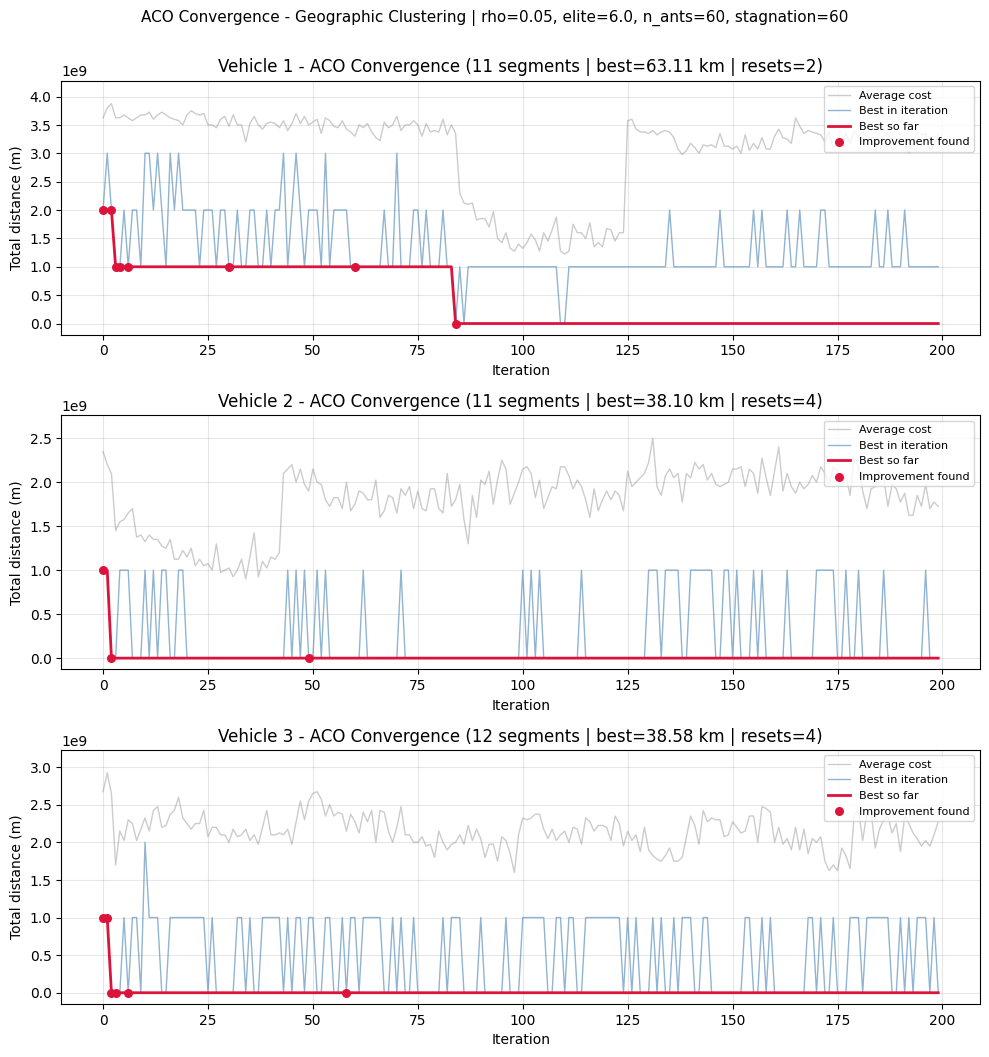

Plot disimpan ke aco_convergence_improved.png


In [ ]:
active_results = [r for r in vehicle_results if r['history']]
fig, axes = plt.subplots(
    nrows=max(1, len(active_results)), ncols=1,
    figsize=(10, 3.5 * max(1, len(active_results))), squeeze=False
)
for pi, r in enumerate(active_results):
    ax = axes[pi, 0]
    h = r['history']
    iters = range(len(h['best_so_far']))

    ax.plot(iters, h['avg_cost'],
            label='Average cost', alpha=0.4, color='gray', linewidth=1)
    ax.plot(iters, h['best_in_iteration'],
            label='Best in iteration', alpha=0.6, color='steelblue', linewidth=1)
    ax.plot(iters, h['best_so_far'],
            label='Best so far', color='crimson', linewidth=2)

    # Tandai titik perbaikan best-so-far dengan marker
    prev = float('inf')
    improve_iters, improve_vals = [], []
    for it, val in enumerate(h['best_so_far']):
        if val < prev - 1e-3:
            improve_iters.append(it)
            improve_vals.append(val)
            prev = val
    if improve_iters:
        ax.scatter(improve_iters, improve_vals,
                   color='crimson', s=30, zorder=5, label='Improvement found')

    reset_cnt = h.get('reset_count', 0)
    n_seg = len(r['seg_ids'])
    best_km = r['total_dist_m'] / 1000
    ax.set_title(
        f"Vehicle {r['vehicle_id']} - ACO Convergence "
        f"({n_seg} segments | best={best_km:.2f} km | resets={reset_cnt})"
    )
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Total distance (m)")
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

    # Sedikit ruang di atas agar title tidak menempel garis
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax + (ymax - ymin) * 0.05)

plt.suptitle(
    f"ACO Convergence - Geographic Clustering | "
    f"rho=0.05, elite=6.0, n_ants=60, stagnation=60",
    fontsize=11, y=1.002
)
plt.tight_layout()
plt.savefig('aco_convergence_improved.png', dpi=120, bbox_inches='tight')
plt.show()
print("Plot disimpan ke aco_convergence_improved.png")


## 9. Inspect Chosen Traversal Directions

In [ ]:
def segment_orientation_summary(order, orientations, segments, D,
                                 water_source_indices, initial_ws_idx,
                                 tank_capacity=8000, avg_speed_kmh=30.0):
    def dist_to_time(dist_m):
        return (dist_m / 1000.0) / avg_speed_kmh * 60.0

    rows        = []
    current_time = float(OPERATION_START)
    cur_idx     = DEPOT_IDX
    water       = 0

    if initial_ws_idx is not None:
        current_time += dist_to_time(D[cur_idx, initial_ws_idx])
        cur_idx = initial_ws_idx
        water   = tank_capacity

    for step, (si, ori) in enumerate(zip(order, orientations), start=1):
        seg    = segments[si]
        demand = seg.get('demand', 0)
        entry  = seg['a_idx'] if ori == 0 else seg['b_idx']
        exit_  = seg['b_idx'] if ori == 0 else seg['a_idx']

        if water < demand and demand > 0:
            ws, wd = find_nearest_water_source(cur_idx, D, water_source_indices)
            current_time += dist_to_time(wd)
            cur_idx = ws
            water   = tank_capacity

        current_time += dist_to_time(D[cur_idx, entry])
        start_time    = current_time
        current_time += dist_to_time(D[entry, exit_]) + seg.get('service_time_min', 0.0)
        water        -= demand
        cur_idx       = exit_

        rows.append({
            "Step"      : step,
            "Segment"   : seg['name'],
            "Direction" : "A->B" if ori == 0 else "B->A",
            "Demand (L)": seg.get('demand', 0),
            "Start"     : time_to_str(start_time),
            "Finish"    : time_to_str(current_time),
        })

    return pd.DataFrame(rows)


for r in vehicle_results:
    if not r['seg_ids']: continue
    print(f"\nVehicle {r['vehicle_id']} route:")
    display(segment_orientation_summary(
        r['best_order'], r['orientations'], SEGMENTS,
        dist_matrix, WATER_SOURCE_INDICES, r['water_source_idx']
    ))


Vehicle 1 route:


,Step,Segment,Direction,Demand (L),Start,Finish
0,1,Jalan Raya Kertajaya Indah,A->B,6412.5,06:14,06:29
1,2,Jalan Dharmahusada Indah III,B->A,1031.3,06:31,06:34
2,3,Jalan Doktor Insinyur Haji Soekarno,B->A,7125.0,06:54,07:11
3,4,Jalan Arief Rahman Hakim,B->A,1428.8,07:26,07:32
4,5,Jalan Doktor Insinyur Haji Soekarno,B->A,2610.0,07:32,07:39
5,6,Jalan Nginden Semolo,B->A,1500.0,07:48,07:53
6,7,Jalan Raya Nginden,A->B,1920.0,07:53,07:58
7,8,Jalan Semolowaru,A->B,1050.0,08:09,08:13
8,9,Jalan Doktor Insinyur Haji Soekarno,A->B,3750.0,08:15,08:25
9,10,Jalan Kedung Baruk,A->B,5932.5,08:33,08:47



Vehicle 2 route:


,Step,Segment,Direction,Demand (L),Start,Finish
0,1,Jalan Kertajaya,A->B,3543.8,06:07,06:16
1,2,Jalan Dharmahusada Indah I,B->A,1500.0,06:24,06:28
2,3,Jalan Dharma Husada Indah II,B->A,1230.0,06:28,06:32
3,4,Jalan Dharmahusada Indah III,B->A,975.0,06:33,06:35
4,5,Jalan Dharma Husada Indah II,A->B,1500.0,06:38,06:43
5,6,Jalan Raya Kertajaya Indah,A->B,7500.0,06:49,07:08
6,7,Jalan Kertajaya,A->B,4455.0,07:15,07:25
7,8,Jalan Raya Menur,A->B,1743.8,07:29,07:35
8,9,Jalan Raya Menur,B->A,1800.0,07:38,07:45
9,10,Jalan Arief Rahman Hakim,B->A,6142.5,07:47,08:01



Vehicle 3 route:


,Step,Segment,Direction,Demand (L),Start,Finish
0,1,Jalan Doktor Insinyur Haji Soekarno,B->A,3034.5,06:12,06:21
1,2,Jalan Kenjeran,B->A,3750.0,06:21,06:31
2,3,Jalan Raya Mulyosari,A->B,862.5,06:34,06:39
3,4,Jalan Raya ITS,B->A,3090.0,06:43,06:52
4,5,Jalan Dharmahusada Indah Utara XIV,B->A,1518.8,06:59,07:03
5,6,Jalan Dharmahusada Permai,B->A,2205.0,07:03,07:09
6,7,Jalan Doktor Insinyur Haji Soekarno,A->B,3750.0,07:13,07:23
7,8,Jalan Dharmahusada Indah III,A->B,1068.8,07:27,07:30
8,9,Jalan Dharmahusada Indah I,A->B,1500.0,07:30,07:34
9,10,Jalan Doktor Insinyur Haji Soekarno,A->B,2362.5,07:38,07:44


## 10. Water Demand and Refill Simulation

Each vehicle starts at the depot with an empty tank, drives to its assigned water source to fill up (8000 L), then visits segments in order. Water is consumed per segment demand. When the tank is insufficient for the next segment, the vehicle detours to the nearest water source, refills, and continues.


In [ ]:
for r in vehicle_results:
    if not r['seg_ids']: continue
    plan, td, rc, penalty = simulate_route_with_refills(
        r['best_order'], r['orientations'], SEGMENTS, dist_matrix,
        WATER_SOURCE_INDICES, r['water_source_idx'], r['tank_capacity'], RETURN_TO_DEPOT)
    r['refill_plan'] = plan
    r['total_dist_with_refills_m'] = td
    r['refill_count'] = rc
    r['time_penalty'] = penalty
    r['is_feasible']  = (penalty == 0.0)

    # Cetak ringkasan waktu per kendaraan
    print(f"\nVehicle {r['vehicle_id']:2d}: feasible={'YES' if r['is_feasible'] else 'NO'} | "
        f"route_only={r['total_dist_m']:,.0f}m | with_refills={td:,.0f}m | "
        f"refills={rc} | penalty={penalty:.0f}")
    for leg in plan:
        if leg['type'] == 'constraint_violation':
            print(f"   [VIOLATION] {leg['label']}")
        elif leg['type'] == 'drive_to_water':
            print(f"   REFILL: {leg['label']} (+{leg['distance_m']:,.0f}m)")
    seg_demand = sum(SEGMENTS[i]['demand'] for i in r['seg_ids'])
    print(f"\nVehicle {r['vehicle_id']:2d}: route_only={r['total_dist_m']:,.0f}m | "
          f"with_refills={td:,.0f}m | refills={rc} | demand={seg_demand:,.0f}L")
    for leg in plan:
        if leg['type'] == 'drive_to_water':
            print(f"   REFILL: {leg['label']} (+{leg['distance_m']:,.0f}m)")

print(f"\n{'='*80}")
print("FLEET SUMMARY WITH REFILLS")
print(f"{'='*80}")
tfdr = sum(r.get('total_dist_with_refills_m', 0) for r in vehicle_results)
tr = sum(r.get('refill_count', 0) for r in vehicle_results)
for r in vehicle_results:
    if r['seg_ids']:
        print(f"  Vehicle {r['vehicle_id']:2d}: {r.get('total_dist_with_refills_m',0):>10,.0f} m "
              f"({r.get('total_dist_with_refills_m',0)/1000:.2f} km)  refills={r.get('refill_count',0)}")
print(f"  Fleet total : {tfdr:>10,.0f} m ({tfdr/1000:.2f} km)  total refills={tr}")



Vehicle  1: feasible=YES | route_only=63,105m | with_refills=63,105m | refills=6 | penalty=0
   REFILL: Depot -> Water Selokan Dekat Pizza Hut Merr (initial fill) @ 06:08 (+4,263m)
   REFILL: Refill @ Water Selokan Dekat Resto Niki Sae (sisa=556L) @ 06:36 (+809m)
   REFILL: Refill @ Water Selokan Depan Perumahan YKP Pandugo (sisa=875L) @ 07:16 (+2,396m)
   REFILL: Refill @ Water Selokan Depan Samator (sisa=541L) @ 08:02 (+2,017m)
   REFILL: Refill @ Water Selokan Depan Samator (sisa=3200L) @ 08:30 (+2,393m)
   REFILL: Refill @ Water Selokan Depan Samator (sisa=2068L) @ 08:49 (+1,010m)

Vehicle  1: route_only=63,105m | with_refills=63,105m | refills=6 | demand=36,855L
   REFILL: Depot -> Water Selokan Dekat Pizza Hut Merr (initial fill) @ 06:08 (+4,263m)
   REFILL: Refill @ Water Selokan Dekat Resto Niki Sae (sisa=556L) @ 06:36 (+809m)
   REFILL: Refill @ Water Selokan Depan Perumahan YKP Pandugo (sisa=875L) @ 07:16 (+2,396m)
   REFILL: Refill @ Water Selokan Depan Samator (sisa=541L) 

## 11. Reconstruct Full Route Geometry with OSRM Route

In [ ]:
route_cache = {}

def route_key(p1, p2):
    return (round(p1[0],6), round(p1[1],6), round(p2[0],6), round(p2[1],6))

def osrm_route(p1, p2, overview="full", geometries="geojson"):
    key = route_key(p1, p2)
    if key in route_cache: return route_cache[key]
    coords = f"{p1[1]:.6f},{p1[0]:.6f};{p2[1]:.6f},{p2[0]:.6f}"
    url = (f"{OSRM_BASE}/route/v1/{PROFILE}/{coords}"
           f"?overview={overview}&geometries={geometries}&steps=false")
    r = requests.get(url, timeout=120); r.raise_for_status()
    data = r.json()
    if data.get("code") != "Ok": raise RuntimeError(data)
    route = data["routes"][0]; geom = route["geometry"]["coordinates"]
    latlon = [(lat, lon) for lon, lat in geom]
    out = {"distance_m": float(route["distance"]), "duration_s": float(route["duration"]),
           "geometry_latlon": latlon, "raw": data}
    route_cache[key] = out
    return out

print("osrm_route helper ready.")

for r in vehicle_results:
    if not r['seg_ids']:
        r['full_route_coords'] = []; r['leg_summaries'] = []; continue
    frc = []; ls = []
    for i, leg in enumerate(r.get('refill_plan', []), start=1):
        if leg['type'] == 'constraint_violation':   # skip, tidak ada koordinat
            continue
        fp = SNAPPED_POINTS[leg['from_idx']]; tp = SNAPPED_POINTS[leg['to_idx']]
        res = osrm_route(fp, tp)
        geom = res['geometry_latlon']
        if frc and geom: geom = geom[1:]
        frc.extend(geom)
        ls.append({'leg_no':i, 'type':leg['type'], 'label':leg['label'],
                'distance_m':res['distance_m'], 'duration_min':res['duration_s']/60.0})
    r['full_route_coords'] = frc; r['leg_summaries'] = ls
    rtm = sum(x['distance_m'] for x in ls)
    print(f"Vehicle {r['vehicle_id']:2d}: ACO={r['total_dist_m']:,.0f}m  "
          f"w/refills={r.get('total_dist_with_refills_m',0):,.0f}m  "
          f"OSRM_recon={rtm:,.0f}m  refills={r.get('refill_count',0)}")


osrm_route helper ready.
Vehicle  1: ACO=63,105m  w/refills=63,105m  OSRM_recon=63,105m  refills=6
Vehicle  2: ACO=38,102m  w/refills=38,102m  OSRM_recon=38,102m  refills=6
Vehicle  3: ACO=38,583m  w/refills=38,583m  OSRM_recon=38,583m  refills=5


## 12. Visualize on Interactive OSM Map

In [ ]:
output_dir = Path("Output")
output_dir.mkdir(exist_ok=True)

VEHICLE_COLORS = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd',
                  '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf']

def add_arrows(fmap, coords, color, n_arrows=6, arrow_size=12):
    if len(coords) < 2: return
    cd = [0.0]
    for i in range(1, len(coords)):
        cd.append(cd[-1] + math.hypot(coords[i][0]-coords[i-1][0], coords[i][1]-coords[i-1][1]))
    total = cd[-1]
    if total == 0: return
    for frac in [(k+1)/(n_arrows+1) for k in range(n_arrows)]:
        target = frac * total; si = 1
        while si < len(cd)-1 and cd[si] < target: si += 1
        sl = cd[si] - cd[si-1]; t = (target - cd[si-1])/sl if sl > 0 else 0
        lat = coords[si-1][0] + t*(coords[si][0]-coords[si-1][0])
        lon = coords[si-1][1] + t*(coords[si][1]-coords[si-1][1])
        dy, dx = coords[si][0]-coords[si-1][0], coords[si][1]-coords[si-1][1]
        b = math.degrees(math.atan2(dx, dy)) % 360
        html = (f'<div style="width:0;height:0;border-left:{arrow_size//2}px solid transparent;'
                f'border-right:{arrow_size//2}px solid transparent;'
                f'border-bottom:{arrow_size}px solid {color};'
                f'transform:rotate({b:.1f}deg);transform-origin:50% 100%;'
                f'opacity:0.85;margin-top:-{arrow_size}px;"></div>')
        folium.Marker((lat,lon), icon=folium.DivIcon(html=html, icon_size=(arrow_size,arrow_size))).add_to(fmap)

def build_vehicle_map(r_list, title_label="All Vehicles"):
    m = folium.Map(location=DEPOT, zoom_start=13,
        tiles='https://tile.openstreetmap.de/{z}/{x}/{y}.png', attr='OSM contributors')

    # Marker Depot Utama
    folium.Marker(DEPOT, tooltip='DEPOT', icon=folium.Icon(color='red', icon='home', prefix='fa')).add_to(m)

    for i_vehicle, r in enumerate(r_list):
        if not r['seg_ids']: continue

        vc = VEHICLE_COLORS[(r['vehicle_id']-1) % len(VEHICLE_COLORS)]
        vl = f"Vehicle {r['vehicle_id']}"

        # --- FITUR FILTER LAYER ---
        # Atur agar hanya rute pertama (index 0) yang tampil otomatis saat peta dibuka.
        # Sisanya disembunyikan (show=False) agar peta tidak penuh/kusut.
        is_visible = True if i_vehicle == 0 else False
        vehicle_group = folium.FeatureGroup(name=vl, show=is_visible)

        # Ambil rencana perjalanan lengkap (refill_plan)
        plan = r.get('refill_plan', [])

        for i, leg in enumerate(plan, start=1):
            if leg['type'] == 'constraint_violation':   # skip, tidak ada koordinat
                continue
            fp = SNAPPED_POINTS[leg['from_idx']]
            tp = SNAPPED_POINTS[leg['to_idx']]

            # Ambil rute asli jalan raya lewat OSRM
            res = osrm_route(fp, tp)

            # Tentukan gaya garis: Putus-putus jika sedang ambil air (Refill)
            line_dash = '10, 10' if leg['type'] == 'drive_to_water' else None

            # Gambar Garis Rute (dimasukkan ke vehicle_group, bukan m)
            folium.PolyLine(
                res['geometry_latlon'],
                color=vc,
                weight=4,
                opacity=0.8,
                dash_array=line_dash,
                tooltip=f"{vl} Langkah {i}: {leg['label']}"
            ).add_to(vehicle_group)

            # Penomoran di setiap titik henti
            icon_color = "blue" if leg['type'] == 'drive_to_water' else vc

            folium.Marker(
                tp,
                icon=folium.DivIcon(html=f'''
                    <div style="font-size:9pt; font-weight:bold; color:white;
                    background:{icon_color}; border:2px solid white; border-radius:5px;
                    padding:2px 5px; min-width:20px; text-align:center;
                    box-shadow:0 0 4px rgba(0,0,0,0.5);">
                        {i}
                    </div>'''),
                tooltip=f"{vl} Urutan ke-{i}: {leg['label']}"
            ).add_to(vehicle_group)

        # Tambahkan seluruh grup kendaraan ini ke peta
        vehicle_group.add_to(m)

    # Memunculkan kotak filter/Layer Control di pojok kanan atas
    folium.LayerControl(collapsed=False).add_to(m)

    return m

print("Generating combined map...")
m_all = build_vehicle_map(vehicle_results)
m_all.save(output_dir / "map_all_vehicles_aco.html")
print(f"  Saved: {output_dir / 'map_all_vehicles_aco.html'}")

active = [r for r in vehicle_results if r['seg_ids']]
print(f"Generating {len(active)} individual maps...")
for r in active:
    mv = build_vehicle_map([r])
    fn = output_dir / f"map_vehicle_{r['vehicle_id']}_aco.html"
    mv.save(fn); print(f"  Saved: {fn}")
print("\nDisplaying combined map:")
m_all


Generating combined map...
  Saved: Output\map_all_vehicles_aco.html
Generating 3 individual maps...
  Saved: Output\map_vehicle_1_aco.html
  Saved: Output\map_vehicle_2_aco.html
  Saved: Output\map_vehicle_3_aco.html

Displaying combined map:


### Detailed Result

In [ ]:
r1 = next(r for r in vehicle_results if r['vehicle_id'] == 1)
print(f"Feasible: {r1['is_feasible']}")
print(f"Penalty : {r1['time_penalty']:.0f}")
print()
for leg in r1['refill_plan']:
    print(f"  [{leg['type']:<22}] {leg['label']}")

Feasible: True
Penalty : 0

  [drive_to_water        ] Depot -> Water Selokan Dekat Pizza Hut Merr (initial fill) @ 06:08
  [drive_to_segment      ] Drive to Jalan Raya Kertajaya Indah entry @ 06:14
  [traverse_segment      ] Water Jalan Raya Kertajaya Indah (demand=6412L, selesai @ 06:29)
  [drive_to_segment      ] Drive to Jalan Dharmahusada Indah III entry @ 06:31
  [traverse_segment      ] Water Jalan Dharmahusada Indah III (demand=1031L, selesai @ 06:34)
  [drive_to_water        ] Refill @ Water Selokan Dekat Resto Niki Sae (sisa=556L) @ 06:36
  [drive_to_segment      ] Drive to Jalan Doktor Insinyur Haji Soekarno entry @ 06:54
  [traverse_segment      ] Water Jalan Doktor Insinyur Haji Soekarno (demand=7125L, selesai @ 07:11)
  [drive_to_water        ] Refill @ Water Selokan Depan Perumahan YKP Pandugo (sisa=875L) @ 07:16
  [drive_to_segment      ] Drive to Jalan Arief Rahman Hakim entry @ 07:26
  [traverse_segment      ] Water Jalan Arief Rahman Hakim (demand=1429L, selesai @ 07

In [ ]:
r2 = next(r for r in vehicle_results if r['vehicle_id'] == 2)
print(f"Feasible: {r2['is_feasible']}")
print(f"Penalty : {r2['time_penalty']:.0f}")
print()
for leg in r2['refill_plan']:
    print(f"  [{leg['type']:<22}] {leg['label']}")

Feasible: True
Penalty : 0

  [drive_to_water        ] Depot -> Water Sungai Depan SPBU Manyar (Dekat RS Bedah) (initial fill) @ 06:04
  [drive_to_segment      ] Drive to Jalan Kertajaya entry @ 06:07
  [traverse_segment      ] Water Jalan Kertajaya (demand=3544L, selesai @ 06:16)
  [drive_to_segment      ] Drive to Jalan Dharmahusada Indah I entry @ 06:24
  [traverse_segment      ] Water Jalan Dharmahusada Indah I (demand=1500L, selesai @ 06:28)
  [drive_to_segment      ] Drive to Jalan Dharma Husada Indah II entry @ 06:28
  [traverse_segment      ] Water Jalan Dharma Husada Indah II (demand=1230L, selesai @ 06:32)
  [drive_to_segment      ] Drive to Jalan Dharmahusada Indah III entry @ 06:33
  [traverse_segment      ] Water Jalan Dharmahusada Indah III (demand=975L, selesai @ 06:35)
  [drive_to_water        ] Refill @ Water Selokan Dekat Resto Niki Sae (sisa=751L) @ 06:37
  [drive_to_segment      ] Drive to Jalan Dharma Husada Indah II entry @ 06:38
  [traverse_segment      ] Water J

In [ ]:
r2 = next(r for r in vehicle_results if r['vehicle_id'] == 3)
print(f"Feasible: {r2['is_feasible']}")
print(f"Penalty : {r2['time_penalty']:.0f}")
print()
for leg in r2['refill_plan']:
    print(f"  [{leg['type']:<22}] {leg['label']}")

Feasible: True
Penalty : 0

  [drive_to_water        ] Depot -> Water Selokan Dekat Resto Niki Sae (initial fill) @ 06:06
  [drive_to_segment      ] Drive to Jalan Doktor Insinyur Haji Soekarno entry @ 06:12
  [traverse_segment      ] Water Jalan Doktor Insinyur Haji Soekarno (demand=3034L, selesai @ 06:21)
  [drive_to_segment      ] Drive to Jalan Kenjeran entry @ 06:21
  [traverse_segment      ] Water Jalan Kenjeran (demand=3750L, selesai @ 06:31)
  [drive_to_segment      ] Drive to Jalan Raya Mulyosari entry @ 06:34
  [traverse_segment      ] Water Jalan Raya Mulyosari (demand=862L, selesai @ 06:39)
  [drive_to_water        ] Refill @ Water Sungai Wisma Permai (sisa=353L) @ 06:40
  [drive_to_segment      ] Drive to Jalan Raya ITS entry @ 06:43
  [traverse_segment      ] Water Jalan Raya ITS (demand=3090L, selesai @ 06:52)
  [drive_to_segment      ] Drive to Jalan Dharmahusada Indah Utara XIV entry @ 06:59
  [traverse_segment      ] Water Jalan Dharmahusada Indah Utara XIV (demand=15